In [3]:
!pip install labelme opencv-python matplotlib albumentations

In [2]:
import os
import time
import uuid
import cv2

In [71]:

IMAGES_PATH = os.path.join('data','images')
number_images = 30

In [72]:
cap = cv2.VideoCapture(0)  # try 0 first

if not cap.isOpened():
    print("Camera not found")
else:
    for imgnum in range(number_images):
        ret, frame = cap.read()
        if not ret or frame is None:
            print(f"Failed to grab frame {imgnum}")
            continue
        imgname = os.path.join(IMAGES_PATH, f'{str(uuid.uuid1())}.jpg')
        cv2.imwrite(imgname, frame)
        cv2.imshow('frame', frame)
        time.sleep(0.5)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

cap.release()
cv2.destroyAllWindows()

In [73]:
!labelme

2026-06-24 12:30:34.785 | INFO     | labelme.__main__:main:227 - Starting Labelme 6.3.1
2026-06-24 12:30:47.552 | DEBUG    | labelme.app:_scan_image_files:2733 - found 91 images in 'D:/code_base/face_dectection/data/images'
2026-06-24 12:30:47.558 | DEBUG    | labelme.app:_open_next_image:2197 - setting current row to 0
2026-06-24 12:30:47.565 | DEBUG    | labelme._label_file:read_image_file:182 - Loaded image file: 'D:\\code_base\\face_dectection\\data\\images\\.ipynb_checkpoints\\0a69bbb9-6f93-11f1-ab82-d4ab6168eaec-checkpoint.jpg' in 3ms
2026-06-24 12:30:47.583 | DEBUG    | labelme.app:_load_file:2043 - Created QImage in 17ms
2026-06-24 12:30:47.594 | DEBUG    | labelme.app:_load_file:2060 - Loaded pixmap in 10ms
2026-06-24 12:30:47.596 | INFO     | labelme.app:_load_file:2096 - Loaded file: 'D:\\code_base\\face_dectection\\data\\images\\.ipynb_checkpoints\\0a69bbb9-6f93-11f1-ab82-d4ab6168eaec-checkpoint.jpg' in 34ms
2026-06-24 12:31:20.962 | DEBUG    | labelme.app:_scan_image_files

In [3]:
import tensorflow as tf
import json
import numpy as np
from matplotlib import pyplot as plt

In [4]:
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus: 
    tf.config.experimental.set_memory_growth(gpu, True)

In [5]:

tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'),
 PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]

In [46]:
images = tf.data.Dataset.list_files('data\\images\\*.jpg' )

In [47]:
images.as_numpy_iterator().next()

b'data\\images\\d241c364-6f92-11f1-b159-d4ab6168eaec.jpg'

In [48]:
def load_image(x): 
    byte_img = tf.io.read_file(x)
    img = tf.io.decode_jpeg(byte_img)
    return img

In [49]:
images = images.map(load_image)

In [50]:
images.as_numpy_iterator().next()


array([[[ 28,  30,  27],
        [ 27,  29,  26],
        [ 25,  27,  26],
        ...,
        [ 79, 136, 127],
        [ 77, 134, 125],
        [ 82, 142, 132]],

       [[ 28,  30,  27],
        [ 27,  29,  26],
        [ 26,  28,  27],
        ...,
        [ 80, 137, 128],
        [ 73, 133, 123],
        [ 77, 139, 128]],

       [[ 29,  31,  28],
        [ 28,  30,  27],
        [ 27,  29,  26],
        ...,
        [ 87, 147, 135],
        [ 83, 145, 134],
        [ 86, 149, 138]],

       ...,

       [[105, 133, 136],
        [104, 132, 135],
        [104, 132, 135],
        ...,
        [  3,   1,   4],
        [  3,   1,   4],
        [  2,   0,   3]],

       [[106, 134, 137],
        [105, 133, 136],
        [104, 132, 135],
        ...,
        [  3,   1,   4],
        [  3,   1,   4],
        [  2,   0,   3]],

       [[106, 134, 137],
        [105, 133, 136],
        [104, 132, 135],
        ...,
        [  3,   1,   4],
        [  3,   1,   4],
        [  2,   0,   3]]

In [76]:

type(images)

tensorflow.python.data.ops.dataset_ops.MapDataset

In [83]:

image_generator = images.batch(4).as_numpy_iterator()

In [84]:
plot_images = image_generator.next()

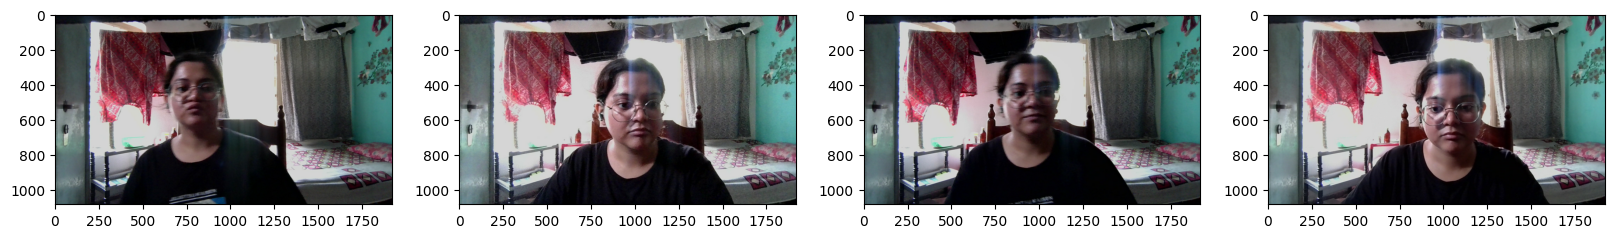

In [85]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, image in enumerate(plot_images):
    ax[idx].imshow(image) 
plt.show()

In [86]:

90*.7

62.99999999999999

In [87]:

90*.15

13.5

In [6]:
import os
for folder in ['train', 'test', 'val']:
    os.makedirs(os.path.join('data', folder, 'images'), exist_ok=True)
    os.makedirs(os.path.join('data', folder, 'labels'), exist_ok=True)

In [7]:
for folder in ['train','test','val']:
    for file in os.listdir(os.path.join('data', folder, 'images')):
        
        filename = file.split('.')[0]+'.json'
        existing_filepath = os.path.join('data','labels', filename)
        if os.path.exists(existing_filepath): 
            new_filepath = os.path.join('data',folder,'labels',filename)
            os.replace(existing_filepath, new_filepath)

In [8]:
import albumentations as alb

In [9]:
augmentor = alb.Compose([alb.RandomCrop(width=450, height=450), 
                         alb.HorizontalFlip(p=0.5), 
                         alb.RandomBrightnessContrast(p=0.2),
                         alb.RandomGamma(p=0.2), 
                         alb.RGBShift(p=0.2), 
                         alb.VerticalFlip(p=0.5)], 
                       bbox_params=alb.BboxParams(format='albumentations', 
                                                  label_fields=['class_labels']))

In [12]:
img

array([[[ 15,  15,  15],
        [ 15,  15,  15],
        [ 17,  13,  18],
        ...,
        [ 35,  35,  23],
        [ 31,  31,  19],
        [ 26,  26,  14]],

       [[ 15,  15,  15],
        [ 15,  15,  15],
        [ 18,  15,  17],
        ...,
        [ 41,  42,  26],
        [ 38,  39,  23],
        [ 35,  36,  20]],

       [[ 16,  17,  15],
        [ 16,  17,  15],
        [ 18,  16,  15],
        ...,
        [ 62,  66,  41],
        [ 64,  70,  47],
        [ 62,  68,  45]],

       ...,

       [[104, 100,  82],
        [104, 100,  82],
        [105, 101,  83],
        ...,
        [  7,   0,   7],
        [  7,   0,   7],
        [  7,   0,   7]],

       [[104,  99,  84],
        [104, 100,  82],
        [105, 101,  83],
        ...,
        [  6,   0,   5],
        [  7,   0,   5],
        [  7,   0,   5]],

       [[104,  99,  84],
        [104,  99,  84],
        [105, 101,  83],
        ...,
        [  6,   0,   5],
        [  7,   0,   5],
        [  6,   0,   4]]

In [54]:
img = cv2.imread(os.path.join('data','train', 'images','0dee4e6a-6f93-11f1-ad47-d4ab6168eaec.jpg'))


In [55]:
with open(os.path.join('data', 'train', 'labels', '0dee4e6a-6f93-11f1-ad47-d4ab6168eaec.json'), 'r') as f:
    label = json.load(f)

In [56]:
label

{'version': '6.3.1',
 'flags': {},
 'shapes': [{'label': 'face',
   'points': [[636.7857142857142, 284.64285714285717],
    [1172.5, 691.7857142857142]],
   'group_id': None,
   'description': '',
   'shape_type': 'rectangle',
   'flags': {},
   'mask': None}],
 'imagePath': '..\\images\\0dee4e6a-6f93-11f1-ad47-d4ab6168eaec.jpg',
 'imageData': None,
 'imageHeight': 1080,
 'imageWidth': 1920}

In [57]:
label['shapes'][0]['points']


[[636.7857142857142, 284.64285714285717], [1172.5, 691.7857142857142]]

In [58]:

coords = [0,0,0,0]
coords[0] = label['shapes'][0]['points'][0][0]
coords[1] = label['shapes'][0]['points'][0][1]
coords[2] = label['shapes'][0]['points'][1][0]
coords[3] = label['shapes'][0]['points'][1][1]

In [59]:
coords


[636.7857142857142, 284.64285714285717, 1172.5, 691.7857142857142]

In [60]:
coords = list(np.divide(coords, [640,480,640,480]))


In [61]:
coords

[0.9949776785714285, 0.5930059523809524, 1.83203125, 1.441220238095238]

In [62]:
# Extract points from JSON
points = label['shapes'][0]['points']
img_w = label['imageWidth']
img_h = label['imageHeight']

# points[0] = top-left, points[1] = bottom-right
x_min = points[0][0] / img_w
y_min = points[0][1] / img_h
x_max = points[1][0] / img_w
y_max = points[1][1] / img_h

coords_normalized = [x_min, y_min, x_max, y_max]
print(coords_normalized)

[0.33165922619047616, 0.2635582010582011, 0.6106770833333334, 0.640542328042328]


In [63]:
print(f"Face center: x={((coords_normalized[0]+coords_normalized[2])/2)*1920:.0f}, y={((coords_normalized[1]+coords_normalized[3])/2)*1080:.0f}")

Face center: x=905, y=488


In [64]:
import albumentations as A
augmentor = A.Compose([
    A.RandomCrop(width=450, height=450, p=1.0),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
], bbox_params=A.BboxParams(
    format='albumentations',
    min_visibility=0.0,  # keep box even if barely visible
    label_fields=['class_labels']
))

In [65]:
augmented = augmentor(image=img, bboxes=[coords_normalized], class_labels=['face'])
print(augmented['bboxes'])

[[0.0, 0.0, 0.08047618442111548, 0.8239682547251383]]


In [66]:
augmented['bboxes'][0][2:]


[0.08047618442111548, 0.8239682547251383]

In [67]:
augmented['bboxes']


[[0.0, 0.0, 0.08047618442111548, 0.8239682547251383]]

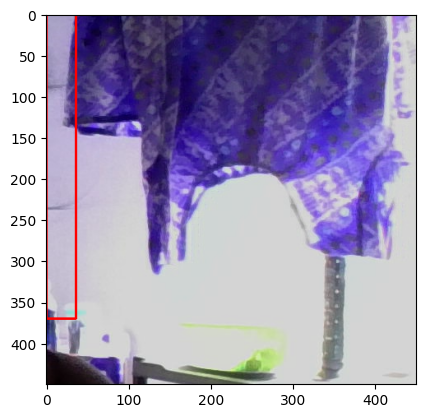

In [68]:
cv2.rectangle(augmented['image'], 
              tuple(np.multiply(augmented['bboxes'][0][:2], [450,450]).astype(int)),
              tuple(np.multiply(augmented['bboxes'][0][2:], [450,450]).astype(int)), 
                    (255,0,0), 2)

plt.imshow(augmented['image'])

In [69]:
for partition in ['train','test','val']: 
    for image in os.listdir(os.path.join('data', partition, 'images')):
        img_path = os.path.join('data', partition, 'images', image)
        img = cv2.imread(img_path)
        
        if img is None:
            print(f"Failed to read: {img_path}, skipping.")
            continue
        
        coords = [0, 0, 0.00001, 0.00001]
        label_path = os.path.join('data', partition, 'labels', f'{image.split(".")[0]}.json')
        
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                label = json.load(f)
            coords[0] = label['shapes'][0]['points'][0][0]
            coords[1] = label['shapes'][0]['points'][0][1]
            coords[2] = label['shapes'][0]['points'][1][0]
            coords[3] = label['shapes'][0]['points'][1][1]
            coords = list(np.divide(coords, [1920, 1080, 1920, 1080]))
        
        try: 
            for x in range(60):
                augmented = augmentor(image=img, bboxes=[coords], class_labels=['face'])
                cv2.imwrite(os.path.join('aug_data', partition, 'images', f'{image.split(".")[0]}.{x}.jpg'), augmented['image'])
                
                annotation = {}
                annotation['image'] = image
                
                if os.path.exists(label_path):
                    if len(augmented['bboxes']) == 0: 
                        annotation['bbox'] = [0, 0, 0, 0]
                        annotation['class'] = 0 
                    else: 
                        annotation['bbox'] = augmented['bboxes'][0]
                        annotation['class'] = 1
                else: 
                    annotation['bbox'] = [0, 0, 0, 0]
                    annotation['class'] = 0 
                
                with open(os.path.join('aug_data', partition, 'labels', f'{image.split(".")[0]}.{x}.json'), 'w') as f:
                    json.dump(annotation, f)
                    
        except Exception as e:
            print(f"Error on {image}: {e}")

In [70]:
def load_image(x):
    byte_img = tf.io.read_file(x)
    img = tf.io.decode_jpeg(byte_img)
    return img

In [71]:
train_images = tf.data.Dataset.list_files('aug_data\\train\\images\\*.jpg', shuffle=False)
train_images = train_images.map(load_image)
train_images = train_images.map(lambda x: tf.image.resize(x, (120,120)))
train_images = train_images.map(lambda x: x/255)

In [72]:
test_images = tf.data.Dataset.list_files('aug_data\\test\\images\\*.jpg', shuffle=False)
test_images = test_images.map(load_image)
test_images = test_images.map(lambda x: tf.image.resize(x, (120,120)))
test_images = test_images.map(lambda x: x/255)

In [73]:

val_images = tf.data.Dataset.list_files('aug_data\\val\\images\\*.jpg', shuffle=False)
val_images = val_images.map(load_image)
val_images = val_images.map(lambda x: tf.image.resize(x, (120,120)))
val_images = val_images.map(lambda x: x/255)

In [74]:
train_images.as_numpy_iterator().next()


array([[[3.98100495e-01, 7.01041639e-01, 6.99203432e-01],
        [3.87071073e-01, 6.92953408e-01, 6.92953408e-01],
        [3.80882353e-01, 6.86764717e-01, 6.91666663e-01],
        ...,
        [1.84436277e-01, 1.25245094e-01, 1.45036772e-01],
        [1.54901966e-01, 8.82352963e-02, 1.11764707e-01],
        [1.15502454e-01, 6.43382370e-02, 7.59803951e-02]],

       [[3.94424021e-01, 6.84007347e-01, 6.80085778e-01],
        [3.74509811e-01, 6.73590660e-01, 6.66544139e-01],
        [3.68566185e-01, 6.74448550e-01, 6.74448550e-01],
        ...,
        [1.68566182e-01, 1.05637252e-01, 1.17463239e-01],
        [1.06556371e-01, 4.10539210e-02, 5.28799035e-02],
        [1.30637258e-01, 5.56372553e-02, 7.62254894e-02]],

       [[3.85477930e-01, 6.70772076e-01, 6.66850507e-01],
        [3.78492653e-01, 6.78002477e-01, 6.69669092e-01],
        [3.64644617e-01, 6.74448550e-01, 6.62683845e-01],
        ...,
        [2.00551465e-01, 1.26041666e-01, 1.33884802e-01],
        [7.43872523e-02, 4.59

In [75]:

def load_labels(label_path):
    with open(label_path.numpy(), 'r', encoding = "utf-8") as f:
        label = json.load(f)
        
    return [label['class']], label['bbox']

In [76]:

train_labels = tf.data.Dataset.list_files('aug_data\\train\\labels\\*.json', shuffle=False)
train_labels = train_labels.map(lambda x: tf.py_function(load_labels, [x], [tf.uint8, tf.float16]))

In [77]:
test_labels = tf.data.Dataset.list_files('aug_data\\test\\labels\\*.json', shuffle=False)
test_labels = test_labels.map(lambda x: tf.py_function(load_labels, [x], [tf.uint8, tf.float16]))

In [78]:
val_labels = tf.data.Dataset.list_files('aug_data\\val\\labels\\*.json', shuffle=False)
val_labels = val_labels.map(lambda x: tf.py_function(load_labels, [x], [tf.uint8, tf.float16]))

In [79]:
train_labels.as_numpy_iterator().next()


(array([0], dtype=uint8), array([0., 0., 0., 0.], dtype=float16))

In [80]:
len(train_images), len(train_labels), len(test_images), len(test_labels), len(val_images), len(val_labels)

(3780, 3780, 840, 840, 780, 780)

In [81]:

train = tf.data.Dataset.zip((train_images, train_labels))
train = train.shuffle(5000)
train = train.batch(8)
train = train.prefetch(4)

In [82]:
test = tf.data.Dataset.zip((test_images, test_labels))
test = test.shuffle(1300)
test = test.batch(8)
test = test.prefetch(4)

In [83]:

val = tf.data.Dataset.zip((val_images, val_labels))
val = val.shuffle(1000)
val = val.batch(8)
val = val.prefetch(4)

In [84]:
train.as_numpy_iterator().next()[1]



(array([[0],
        [0],
        [1],
        [0],
        [1],
        [1],
        [1],
        [1]], dtype=uint8),
 array([[0.    , 0.    , 0.    , 0.    ],
        [0.    , 0.    , 0.    , 0.    ],
        [0.869 , 0.6274, 1.    , 1.    ],
        [0.    , 0.    , 0.    , 0.    ],
        [0.    , 0.    , 0.1891, 0.439 ],
        [0.05  , 0.4014, 0.9785, 1.    ],
        [0.3596, 0.    , 1.    , 0.826 ],
        [0.3145, 0.    , 1.    , 1.    ]], dtype=float16))

In [85]:
data_samples = train.as_numpy_iterator()


In [86]:
res = data_samples.next()


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


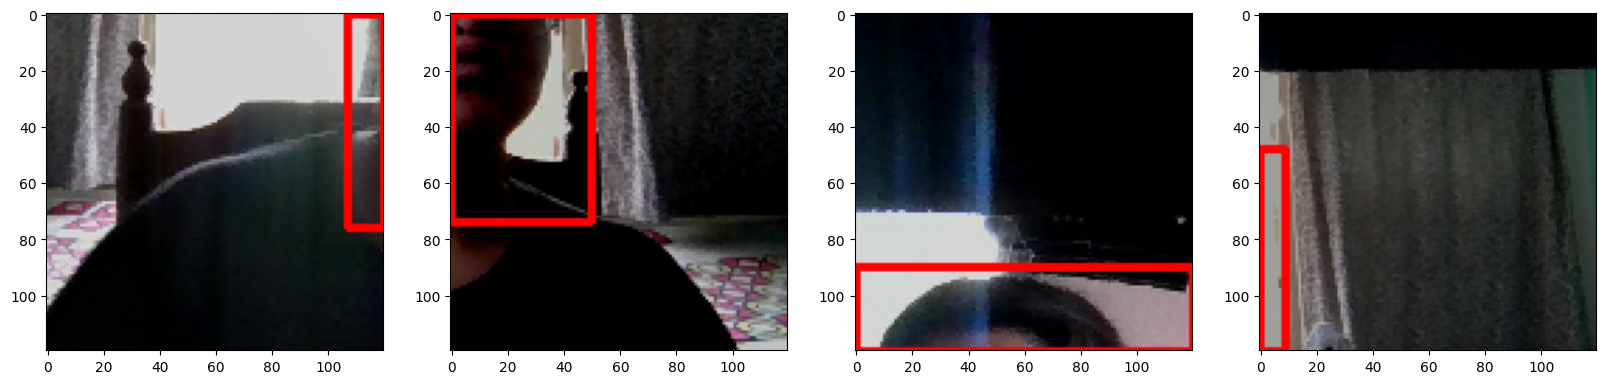

In [89]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx in range(4): 
    sample_image = res[0][idx].copy()
    sample_coords = res[1][1][idx]
    
    cv2.rectangle(sample_image, 
                  tuple(np.multiply(sample_coords[:2], [120,120]).astype(int)),
                  tuple(np.multiply(sample_coords[2:], [120,120]).astype(int)), 
                        (255,0,0), 2)
    ax[idx].imshow(sample_image)

In [90]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, Dense, GlobalMaxPooling2D
from tensorflow.keras.applications import VGG16

In [91]:
vgg = VGG16(include_top=False)


58889256/58889256 [==============================] - 197s 3us/step


In [92]:
vgg.summary()


Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, None, None, 3)]   0         
                                                                 
 block1_conv1 (Conv2D)       (None, None, None, 64)    1792      
                                                                 
 block1_conv2 (Conv2D)       (None, None, None, 64)    36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, None, None, 64)    0         
                                                                 
 block2_conv1 (Conv2D)       (None, None, None, 128)   73856     
                                                                 
 block2_conv2 (Conv2D)       (None, None, None, 128)   147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, None, None, 128)   0     

In [93]:
def build_model(): 
    input_layer = Input(shape=(120,120,3))
    
    vgg = VGG16(include_top=False)(input_layer)

    # Classification Model  
    f1 = GlobalMaxPooling2D()(vgg)
    class1 = Dense(2048, activation='relu')(f1)
    class2 = Dense(1, activation='sigmoid')(class1)
    
    # Bounding box model
    f2 = GlobalMaxPooling2D()(vgg)
    regress1 = Dense(2048, activation='relu')(f2)
    regress2 = Dense(4, activation='sigmoid')(regress1)
    
    facetracker = Model(inputs=input_layer, outputs=[class2, regress2])
    return facetracker

In [95]:
train.as_numpy_iterator().next()[1]

(array([[1],
        [0],
        [1],
        [1],
        [1],
        [0],
        [1],
        [1]], dtype=uint8),
 array([[0.1665  , 0.010956, 0.8887  , 1.      ],
        [0.      , 0.      , 0.      , 0.      ],
        [0.3801  , 0.2893  , 1.      , 1.      ],
        [0.06775 , 0.      , 1.      , 1.      ],
        [0.0808  , 0.3892  , 1.      , 1.      ],
        [0.      , 0.      , 0.      , 0.      ],
        [0.1059  , 0.1316  , 1.      , 1.      ],
        [0.      , 0.0119  , 0.8477  , 1.      ]], dtype=float16))

In [96]:
facetracker = build_model()


In [97]:
facetracker.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 120, 120, 3  0           []                               
                                )]                                                                
                                                                                                  
 vgg16 (Functional)             (None, None, None,   14714688    ['input_2[0][0]']                
                                512)                                                              
                                                                                                  
 global_max_pooling2d (GlobalMa  (None, 512)         0           ['vgg16[0][0]']                  
 xPooling2D)                                                                                  

In [98]:
X, y = train.as_numpy_iterator().next()


In [99]:
X.shape


(8, 120, 120, 3)

In [100]:
classes, coords = facetracker.predict(X)


1/1 [==============================] - 3s 3s/step


In [101]:
classes, coords


(array([[0.4964201 ],
        [0.5079434 ],
        [0.5152354 ],
        [0.48438284],
        [0.49984744],
        [0.511001  ],
        [0.54751086],
        [0.39679575]], dtype=float32),
 array([[0.66741925, 0.48671907, 0.3140205 , 0.29062518],
        [0.62208354, 0.44711635, 0.33671075, 0.30240583],
        [0.6198101 , 0.4690289 , 0.25282487, 0.27936375],
        [0.6401978 , 0.5423064 , 0.36389968, 0.29363492],
        [0.6240222 , 0.53604513, 0.37184533, 0.28787827],
        [0.64292896, 0.40050235, 0.3259901 , 0.2735279 ],
        [0.56567436, 0.54136145, 0.35607842, 0.28196022],
        [0.6484406 , 0.4182418 , 0.20061155, 0.29848707]], dtype=float32))

In [102]:
batches_per_epoch = len(train)
lr_decay = (1./0.75 -1)/batches_per_epoch

In [103]:
opt = tf.keras.optimizers.Adam(learning_rate=0.0001, decay=lr_decay)


In [104]:
def localization_loss(y_true, yhat):            
    delta_coord = tf.reduce_sum(tf.square(y_true[:,:2] - yhat[:,:2]))
                  
    h_true = y_true[:,3] - y_true[:,1] 
    w_true = y_true[:,2] - y_true[:,0] 

    h_pred = yhat[:,3] - yhat[:,1] 
    w_pred = yhat[:,2] - yhat[:,0] 
    
    delta_size = tf.reduce_sum(tf.square(w_true - w_pred) + tf.square(h_true-h_pred))
    
    return delta_coord + delta_size

In [105]:

classloss = tf.keras.losses.BinaryCrossentropy()
regressloss = localization_loss

In [108]:
localization_loss(y[1], coords).numpy()


9.643316

In [109]:
classloss(y[0], classes)


<tf.Tensor: shape=(), dtype=float32, numpy=0.68446183>

In [110]:
regressloss(y[1], coords)


<tf.Tensor: shape=(), dtype=float32, numpy=9.643316>

In [111]:
class FaceTracker(Model): 
    def __init__(self, eyetracker,  **kwargs): 
        super().__init__(**kwargs)
        self.model = eyetracker

    def compile(self, opt, classloss, localizationloss, **kwargs):
        super().compile(**kwargs)
        self.closs = classloss
        self.lloss = localizationloss
        self.opt = opt
    
    def train_step(self, batch, **kwargs): 
        
        X, y = batch
        
        with tf.GradientTape() as tape: 
            classes, coords = self.model(X, training=True)
            
            batch_classloss = self.closs(y[0], classes)
            batch_localizationloss = self.lloss(tf.cast(y[1], tf.float32), coords)
            
            total_loss = batch_localizationloss+0.5*batch_classloss
            
            grad = tape.gradient(total_loss, self.model.trainable_variables)
        
        opt.apply_gradients(zip(grad, self.model.trainable_variables))
        
        return {"total_loss":total_loss, "class_loss":batch_classloss, "regress_loss":batch_localizationloss}
    
    def test_step(self, batch, **kwargs): 
        X, y = batch
        
        classes, coords = self.model(X, training=False)
        
        batch_classloss = self.closs(y[0], classes)
        batch_localizationloss = self.lloss(tf.cast(y[1], tf.float32), coords)
        total_loss = batch_localizationloss+0.5*batch_classloss
        
        return {"total_loss":total_loss, "class_loss":batch_classloss, "regress_loss":batch_localizationloss}
        
    def call(self, X, **kwargs): 
        return self.model(X, **kwargs)

In [112]:
model = FaceTracker(facetracker)


In [113]:
model.compile(opt, classloss, regressloss)


In [114]:
logdir='logs'


In [115]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)


In [116]:
hist = model.fit(train, epochs=10, validation_data=val, callbacks=[tensorboard_callback])


Epoch 1/10
473/473 [==============================] - 35s 58ms/step - total_loss: 1.4716 - class_loss: 0.3397 - regress_loss: 1.3017 - val_total_loss: 1.1927 - val_class_loss: 0.7208 - val_regress_loss: 0.8322
Epoch 2/10
473/473 [==============================] - 33s 57ms/step - total_loss: 0.8125 - class_loss: 0.2097 - regress_loss: 0.7077 - val_total_loss: 0.5901 - val_class_loss: 0.1759 - val_regress_loss: 0.5022
Epoch 3/10
473/473 [==============================] - 32s 57ms/step - total_loss: 0.6488 - class_loss: 0.1753 - regress_loss: 0.5612 - val_total_loss: 0.2189 - val_class_loss: 0.0221 - val_regress_loss: 0.2079
Epoch 4/10
473/473 [==============================] - 32s 57ms/step - total_loss: 0.5606 - class_loss: 0.1528 - regress_loss: 0.4842 - val_total_loss: 0.3309 - val_class_loss: 0.1412 - val_regress_loss: 0.2603
Epoch 5/10
473/473 [==============================] - 32s 58ms/step - total_loss: 0.4648 - class_loss: 0.1300 - regress_loss: 0.3998 - val_total_loss: 0.1291 - 

In [117]:
hist.history


{'total_loss': [0.14342308044433594,
  0.15564027428627014,
  1.775937795639038,
  0.030712250620126724,
  0.024468595162034035,
  0.017255350947380066,
  0.0424748919904232,
  0.03738485649228096,
  0.3292362689971924,
  0.37611669301986694],
 'class_loss': [0.106793612241745,
  0.08671407401561737,
  0.6646201610565186,
  0.014349063858389854,
  0.028454124927520752,
  0.008421672508120537,
  0.009140336886048317,
  0.009371474385261536,
  0.05997849255800247,
  0.22910283505916595],
 'regress_loss': [0.09002627432346344,
  0.11228323727846146,
  1.4436277151107788,
  0.023537717759609222,
  0.010241532698273659,
  0.013044513761997223,
  0.03790472447872162,
  0.03269911929965019,
  0.29924702644348145,
  0.26156526803970337],
 'val_total_loss': [1.1926586627960205,
  0.590122640132904,
  0.21892717480659485,
  0.3309240937232971,
  0.12912437319755554,
  0.019785139709711075,
  0.032391294836997986,
  1.1296229362487793,
  0.03988789767026901,
  0.057109542191028595],
 'val_class_l

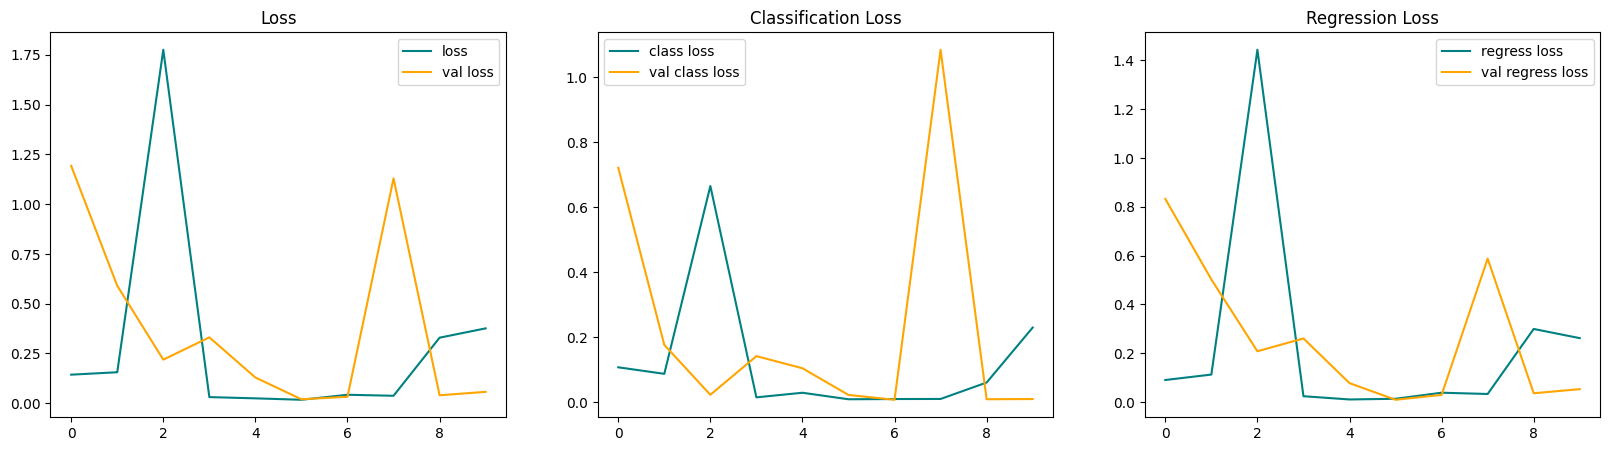

In [118]:
fig, ax = plt.subplots(ncols=3, figsize=(20,5))

ax[0].plot(hist.history['total_loss'], color='teal', label='loss')
ax[0].plot(hist.history['val_total_loss'], color='orange', label='val loss')
ax[0].title.set_text('Loss')
ax[0].legend()

ax[1].plot(hist.history['class_loss'], color='teal', label='class loss')
ax[1].plot(hist.history['val_class_loss'], color='orange', label='val class loss')
ax[1].title.set_text('Classification Loss')
ax[1].legend()

ax[2].plot(hist.history['regress_loss'], color='teal', label='regress loss')
ax[2].plot(hist.history['val_regress_loss'], color='orange', label='val regress loss')
ax[2].title.set_text('Regression Loss')
ax[2].legend()

plt.show()

In [119]:
test_data = test.as_numpy_iterator()


In [120]:
test_sample = test_data.next()


In [128]:
yhat = facetracker.predict(test_sample[0])


1/1 [==============================] - 0s 151ms/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


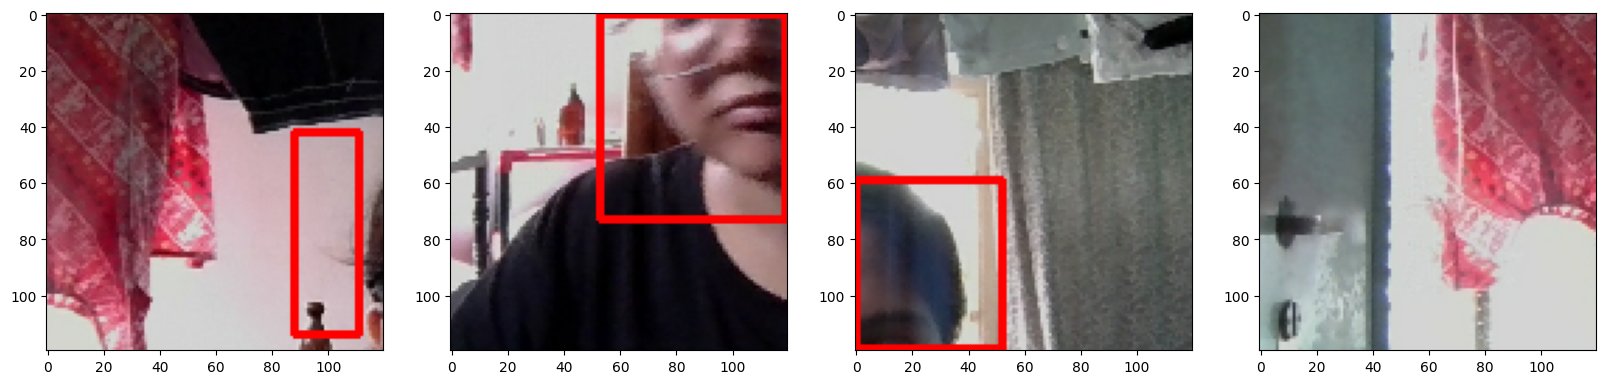

In [129]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx in range(4): 
    sample_image = test_sample[0][idx].copy()
    sample_coords = yhat[1][idx]
    
    if yhat[0][idx] > 0.9:
        cv2.rectangle(sample_image, 
                      tuple(np.multiply(sample_coords[:2], [120,120]).astype(int)),
                      tuple(np.multiply(sample_coords[2:], [120,120]).astype(int)), 
                            (255,0,0), 2)
    
    ax[idx].imshow(sample_image)

In [124]:
from tensorflow.keras.models import load_model


In [125]:
facetracker.save('facetracker.h5')


In [131]:
facetracker = load_model('facetracker.h5')


In [132]:
facetracker.compile(optimizer='adam', loss=['binary_crossentropy', 'mae'])

In [ ]:
cap = cv2.VideoCapture(1)

cv2.namedWindow('EyeTrack', cv2.WINDOW_NORMAL)
cv2.setWindowProperty('EyeTrack', cv2.WND_PROP_FULLSCREEN, cv2.WINDOW_FULLSCREEN)

while cap.isOpened():
    _ , frame = cap.read()
    frame = frame[50:500, 50:500,:]
    
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    resized = tf.image.resize(rgb, (120,120))
    
    yhat = facetracker.predict(np.expand_dims(resized/255,0))
    sample_coords = yhat[1][0]
    
    if yhat[0][0] > 0.5: 
        cv2.rectangle(frame, 
                      tuple(np.multiply(sample_coords[:2], [450,450]).astype(int)),
                      tuple(np.multiply(sample_coords[2:], [450,450]).astype(int)), 
                            (255,0,0), 2)
        cv2.rectangle(frame, 
                      tuple(np.add(np.multiply(sample_coords[:2], [450,450]).astype(int), 
                                    [0,-30])),
                      tuple(np.add(np.multiply(sample_coords[:2], [450,450]).astype(int),
                                    [80,0])), 
                            (255,0,0), -1)
        cv2.putText(frame, 'face', tuple(np.add(np.multiply(sample_coords[:2], [450,450]).astype(int),
                                               [0,-5])),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2, cv2.LINE_AA)
    
    frame = cv2.resize(frame, (1920, 1080))
    cv2.imshow('EyeTrack', frame)
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()